In [90]:
# ============================================
# LOAD SAVED MODEL (Skip training if possible)
# ============================================
# Run this cell FIRST if you want to load a previously trained model
# This avoids having to re-run all the training cells

import os
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = './pokemon_model.pth'
IMG_SIZE = 224  # ResNet50 standard input size (upgraded from 128 for better accuracy)
NUM_CLASSES = 1000
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
USE_PRETRAINED_WEIGHTS = False  # Set True only if SSL/certificates are configured

def create_resnet50_model(num_classes, use_pretrained=False):
    weights = models.ResNet50_Weights.DEFAULT if use_pretrained else None
    try:
        model = models.resnet50(weights=weights)
    except Exception as e:
        print(f"Warning: could not load pretrained weights ({e}). Falling back to random init.")
        model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

if os.path.exists(MODEL_PATH):
    print(f"✓ Found saved model at {MODEL_PATH}")
    # No need to download pretrained weights if we are loading a saved checkpoint.
    model = create_resnet50_model(NUM_CLASSES, use_pretrained=False).to(device)
    try:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.eval()
        model_size = os.path.getsize(MODEL_PATH) / 1024 / 1024
        print(f"✓ Model loaded successfully! ({model_size:.2f} MB)")
        print(f"✓ Device: {device}")
        print(f"\nYou can now:")
        print(f"  - Skip training cells and go directly to evaluation")
        print(f"  - Use model for predictions")
        print(f"  - Run camera_pokemon_recognizer.py")
    except RuntimeError as e:
        print("⚠ Existing checkpoint architecture does not match ResNet50.")
        print(f"Details: {e}")
        print("Please train ResNet50 and save a new checkpoint.")
        model = None
else:
    print(f"⚠ No saved model found at {MODEL_PATH}")
    print(f"Run the training cells below to train and save a new model")
    model = None


✓ Found saved model at ./pokemon_model.pth
✓ Model loaded successfully! (97.79 MB)
✓ Device: mps

You can now:
  - Skip training cells and go directly to evaluation
  - Use model for predictions
  - Run camera_pokemon_recognizer.py


1. Prerequisites

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import glob
import zipfile
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os
import json

In [92]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [93]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [94]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.


2. Importing the dataset

In [95]:
print('Current working directory:', os.getcwd())
print('\nFiles in current directory:')
for f in os.listdir('.'):
    print(' -', f)

# If any .zip files exist, show the first few entries
zips = glob.glob('*.zip')
if zips:
    print('\nFound zip files:')
    for z in zips:
        print(' -', z)
        try:
            with zipfile.ZipFile(z) as zf:
                print('   zip contents (first 20):', zf.namelist()[:20])
        except Exception as e:
            print('   failed to read zip:', e)

# Try to locate a likely CSV and read it
candidates = ['metadata.csv', 'pokemon.csv']
found = False
for name in candidates:
    if os.path.exists(name):
        print(f"\nLoading {name} with pandas...")
        df = pd.read_csv(name)
        print(df.head())
        print('\nInfo:')
        print(df.info())
        found = True
        break

# If not in current dir, walk subfolders and try to find the CSV
if not found:
    for root, dirs, files in os.walk('.'):
        for f in files:
            if f in candidates:
                path = os.path.join(root, f)
                print(f"\nFound {f} at {path}, loading...")
                df = pd.read_csv(path)
                print(df.head())
                print('\nInfo:')
                print(df.info())
                found = True
                break
        if found:
            break

if not found:
    print('\nNo candidate CSV found. If download produced a zip, unzip it or check subfolders.')
    print('If using kaggle CLI, consider using kaggle.api.dataset_download_files("noodulz/pokemon-dataset-1000", unzip=True)')

Current working directory: /Users/isaaclau128/The-Pokedex-Project

Files in current directory:
 - pokemon-dataset-1000
 - camera_frames_for_finetuning
 - pokemon_model_20260429_021436.pth
 - Pokedex_ResNet50.ipynb
 - test_inference.py
 - verify_setup.py
 - requirements.txt
 - pokemon_model.pth
 - notes.txt
 - classes.json
 - evaluate_on_val.py
 - __pycache__
 - README.md
 - MODEL_SAVE_TEMPLATE.py
 - GETTING_STARTED.md
 - finetune_on_camera_frames.py
 - download_dataset.sh
 - README_DOWNLOAD.md
 - temperature.json
 - model_loading_examples.py
 - .venv
 - test_pokemon_predictions.py
 - .gitattributes
 - collect_camera_frames.py
 - DOMAIN_ADAPTATION_GUIDE.md
 - model_loader.py
 - camera_pokemon_recognizer.py
 - LOAD_MODEL_GUIDE.md
 - COMPLETE_SETUP.md
 - calibrate_temperature.py
 - .git
 - test_camera_preprocessing.py
 - CAMERA_SETUP.md
 - pokemon_model_20260429_135316.pth
 - QUICK_REFERENCE.md
 - archived_ipynb_notebooks
 - setup_camera.sh

Found metadata.csv at ./pokemon-dataset-1000/me

In [96]:
file_path = './pokemon-dataset-1000/metadata.csv'


if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("File loaded successfully.")
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())
    print("\nInfo of the DataFrame:")
    display(df.info())
else:
    print(f"File not found at {file_path}. Please ensure the file is in the correct directory.")

File loaded successfully.

First 5 rows of the DataFrame:


,label,image_path,hp,attack,defense,special-attack,special-defense,speed
0,abomasnow,dataset/abomasnow/abomasnow_8.png,90,92,75,92,85,60
1,abomasnow,dataset/abomasnow/abomasnow_18.png,90,92,75,92,85,60
2,abomasnow,dataset/abomasnow/abomasnow_11.png,90,92,75,92,85,60
3,abomasnow,dataset/abomasnow/abomasnow_16.png,90,92,75,92,85,60
4,abomasnow,dataset/abomasnow/abomasnow_9.png,90,92,75,92,85,60



Info of the DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 26539 entries, 0 to 26538
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   label            26539 non-null  str  
 1   image_path       26539 non-null  str  
 2   hp               26539 non-null  int64
 3   attack           26539 non-null  int64
 4   defense          26539 non-null  int64
 5   special-attack   26539 non-null  int64
 6   special-defense  26539 non-null  int64
 7   speed            26539 non-null  int64
dtypes: int64(6), str(2)
memory usage: 1.6 MB


None

In [97]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)


IMG_SIZE = 224  # ResNet50 standard input size (upgraded from 128 for better accuracy)
BATCH_SIZE = 128  # Batch size (increased for better generalization)
LEARNING_RATE = 0.0001  # Lower learning rate for fine-tuning pretrained weights
NUM_EPOCHS = 25  # Increased for longer training with pretrained weights
NUM_CLASSES = 1000  # Number of Pokemon classes

3. Splitting into testing and training data sets

In [98]:
from sklearn.model_selection import train_test_split

# Split the dataframe into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=seed, stratify=df['label'])

print(f"Training data size: {len(train_df)}")
print(f"Testing data size: {len(test_df)}")

Training data size: 21231
Testing data size: 5308


4. Data Preprocessing

In [99]:
# Set image_base_dir to the parent folder that contains the 'dataset' folder referenced in metadata.csv
# In the metadata the image_path values include a leading 'dataset/...' segment,
# so the correct base is the dataset root (not the nested 'dataset' folder).
image_base_dir = './pokemon-dataset-1000/pokemon-dataset-1000'

# Verify the base exists
if not os.path.exists(image_base_dir):
    raise FileNotFoundError(f"image_base_dir does not exist: {image_base_dir}")

# Create a custom dataset class
class PokemonDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        # Ensure label column exists
        if 'label' not in self.dataframe.columns:
            raise KeyError("Expected 'label' column in metadata.csv")
        # Ensure image_path column exists (common name in this dataset)
        if 'image_path' not in self.dataframe.columns:
            raise KeyError("Expected 'image_path' column in metadata.csv")

        self.classes = sorted(self.dataframe['label'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Use named columns for clarity
        rel_path = str(self.dataframe.loc[idx, 'image_path'])
        # Build full path (rel_path usually contains 'dataset/...' in this CSV)
        img_path = os.path.join(self.img_dir, rel_path)

        if not os.path.exists(img_path):
            # Provide helpful debug info
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = Image.open(img_path).convert('RGB')
        label_name = self.dataframe.loc[idx, 'label']
        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

# Training-time augmentation helps reduce overfitting by making the model
# see slightly different versions of the same Pokemon image.
# Strengthened augmentation for better generalization
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),  # More aggressive crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),  # Add vertical flips
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)
    ], p=0.6),  # Stronger color jitter
    transforms.RandomRotation(20),  # Increased rotation range
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Add translation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/test should stay deterministic so metrics are comparable across epochs.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create train/test datasets and loaders if train_df/test_df are available
try:
    # train_df and test_df are created earlier by train_test_split
    train_dataset = PokemonDataset(dataframe=train_df, img_dir=image_base_dir, transform=train_transform)
    test_dataset = PokemonDataset(dataframe=test_df, img_dir=image_base_dir, transform=eval_transform)

    # macOS + notebook + custom Dataset can fail with multiprocessing spawn/pickle.
    # Keep workers at 0 in notebook cells for stability.
    dataloader_workers = 0
    dataloader_kwargs = dict(num_workers=dataloader_workers)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **dataloader_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **dataloader_kwargs)

    # Backwards compatible name
    pokemon_loader = train_loader
    pokemon_class_names = train_dataset.classes

    print(f'Created train_loader ({len(train_dataset)} samples) and test_loader ({len(test_dataset)} samples)')
except NameError:
    # Fallback: if train_df/test_df are not defined, use the full dataframe 'df'
    pokemon_dataset = PokemonDataset(dataframe=df, img_dir=image_base_dir, transform=eval_transform)
    # macOS + notebook + custom Dataset can fail with multiprocessing spawn/pickle.
    # Keep workers at 0 in notebook cells for stability.
    dataloader_workers = 0
    dataloader_kwargs = dict(num_workers=dataloader_workers)
    pokemon_loader = DataLoader(pokemon_dataset, batch_size=BATCH_SIZE, shuffle=True, **dataloader_kwargs)
    train_loader = pokemon_loader
    test_loader = pokemon_loader
    pokemon_class_names = pokemon_dataset.classes
    print('train_df/test_df not found; using full dataset for both train and test (pokemon_loader)')

# Persist the class ordering used during training so inference can map logits correctly.
with open('classes.json', 'w') as f:
    json.dump(pokemon_class_names, f, indent=2)
print("Saved class order to classes.json")

# Print dataset size and class names
print(f'Pokemon dataset sample count (train): {len(train_loader.dataset)}')
print(f'Pokemon class names ({len(pokemon_class_names)}): {pokemon_class_names}')

# Visualize a batch of training images with their labels
def visualize_pokemon_batch(loader, class_names):
    images, labels = next(iter(loader))
    # Move to CPU (if on GPU) and convert to numpy for matplotlib
    if hasattr(images, 'cpu'):
        images_np = images.cpu().permute(0, 2, 3, 1).numpy()
    else:
        images_np = images.permute(0, 2, 3, 1).numpy()

    labels_np = labels.cpu().numpy() if hasattr(labels, 'cpu') else labels.numpy()

    plt.figure(figsize=(12, 6))
    for i in range(min(len(images_np), 8)): # Visualize up to 8 images
        ax = plt.subplot(2, 4, i + 1)
        # Denormalize and clip for display
        img = images_np[i] * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(class_names[int(labels_np[i])])
        ax.axis('off')
    plt.tight_layout()

    plt.show()#visualize_pokemon_batch(pokemon_loader, pokemon_class_names)


Created train_loader (21231 samples) and test_loader (5308 samples)
Saved class order to classes.json
Pokemon dataset sample count (train): 21231
Pokemon class names (1000): ['abomasnow', 'abra', 'absol', 'accelgor', 'aegislash-shield', 'aerodactyl', 'aggron', 'aipom', 'alakazam', 'alcremie', 'alomomola', 'altaria', 'amaura', 'ambipom', 'amoonguss', 'ampharos', 'annihilape', 'anorith', 'appletun', 'applin', 'araquanid', 'arbok', 'arboliva', 'arcanine', 'arceus', 'archen', 'archeops', 'arctibax', 'arctovish', 'arctozolt', 'ariados', 'armaldo', 'armarouge', 'aromatisse', 'aron', 'arrokuda', 'articuno', 'audino', 'aurorus', 'avalugg', 'axew', 'azelf', 'azumarill', 'azurill', 'bagon', 'baltoy', 'banette', 'barbaracle', 'barboach', 'barraskewda', 'basculegion-male', 'basculin-red-striped', 'bastiodon', 'baxcalibur', 'bayleef', 'beartic', 'beautifly', 'beedrill', 'beheeyem', 'beldum', 'bellibolt', 'bellossom', 'bellsprout', 'bergmite', 'bewear', 'bibarel', 'bidoof', 'binacle', 'bisharp', 'bl

5. Model Architecture

In [100]:
# Build a ResNet50 classifier and replace its final layer for Pokemon classes

def create_resnet50_model(num_classes, use_pretrained=False):
    weights = models.ResNet50_Weights.DEFAULT if use_pretrained else None
    try:
        model = models.resnet50(weights=weights)
    except Exception as e:
        print(f"Warning: could not load pretrained weights ({e}). Falling back to random init.")
        model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# Determine the device to use
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

# Use pretrained ImageNet weights for better transfer learning
model = create_resnet50_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_WEIGHTS).to(device)

# Quick sanity checks
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
dummy_output = model(dummy_input)
print(f"Output shape: {dummy_output.shape}")


Using device: mps
Model parameters: 25,557,032
Output shape: torch.Size([2, 1000])


6. Loss Function

In [101]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Ensure NUM_CLASSES matches the dataset if available
try:
    NUM_CLASSES = len(pokemon_class_names)
    print(f"Setting NUM_CLASSES to {NUM_CLASSES} based on dataset classes")
except NameError:
    print('pokemon_class_names not found; using existing NUM_CLASSES value')

# Create model and move to device with pretrained weights
model = create_resnet50_model(NUM_CLASSES, use_pretrained=USE_PRETRAINED_WEIGHTS).to(device)

WEIGHT_DECAY = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"Using Adam with lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}")

# Define loss function (again, safe to reassign)
criterion = nn.CrossEntropyLoss()

Setting NUM_CLASSES to 1000 based on dataset classes
Using Adam with lr=0.0001, weight_decay=0.0001


7. Training Function

In [102]:
# TODO: Create training function:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    test_loader=None,
    patience=5,
    min_delta=1e-4,
    checkpoint_path='pokemon_model.pth',
):
    # TODO: Initialize lists to store losses and accuracies
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    best_test_loss = float('inf')
    best_state_dict = None
    epochs_without_improvement = 0

    # Add learning rate scheduler for faster convergence
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
    )

    # TODO: For each epoch:
    for epoch in range(num_epochs):
        #       - Set model to training mode
        model.train()
        #       - Initialize running loss and correct predictions
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        #       For each batch:
        for i, (images, labels) in enumerate(train_loader): # Added enumerate to track batch index
            # Move data to device
            images, labels = images.to(device), labels.to(device)

            #       - Zero gradients
            optimizer.zero_grad()
            #       - Forward pass: outputs = model(images)
            outputs = model(images)

            #       - Calculate loss: loss = criterion(outputs, labels)
            loss = criterion(outputs, labels)
            #       - Backward pass: loss.backward()
            loss.backward()
            #       - Update weights: optimizer.step()
            optimizer.step()

            #       - Track statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()


        # TODO: Calculate and print epoch statistics (loss, accuracy)
        epoch_loss = running_loss / total_samples
        epoch_accuracy = correct_predictions / total_samples
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        # Evaluate on test set after each epoch if provided
        if test_loader is not None:
            test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device, detailed=False)
            scheduler.step(test_loss)  # Update LR based on test loss
            if test_loss + min_delta < best_test_loss:
                best_test_loss = test_loss
                best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_without_improvement = 0
                torch.save(best_state_dict, checkpoint_path)
                print(f'  ✓ Saved new best checkpoint to {checkpoint_path}')
            else:
                epochs_without_improvement += 1
        else:
            test_loss, test_accuracy = float('nan'), float('nan')

        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

        if test_loader is not None and epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs (patience={patience}).")
            break

# TODO: Print progress
    # if (epoch + 1) % 10 == 0:
    #     print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        print(f"Restored best model weights from {checkpoint_path}")

    print("\nTraining finished.") # This line should be outside the epoch loop


    # TODO: Return training history for plotting
    return train_losses, train_accuracies, test_losses, test_accuracies # Return test losses and accuracies


Starting evaluation...
Test Loss: 0.9281, Test Accuracy: 0.7670

Classification Report:
                            precision    recall  f1-score   support

                 abomasnow       1.00      1.00      1.00         8
                      abra       0.50      0.38      0.43         8
                     absol       1.00      0.88      0.93         8
                  accelgor       1.00      1.00      1.00         4
          aegislash-shield       1.00      0.67      0.80         3
                aerodactyl       1.00      0.12      0.22         8
                    aggron       1.00      0.88      0.93         8
                     aipom       0.75      0.38      0.50         8
                  alakazam       1.00      0.50      0.67         8
                  alcremie       1.00      1.00      1.00         3
                 alomomola       1.00      0.75      0.86         4
                   altaria       1.00      0.50      0.67         8
                    amaura

/Users/isaaclau128/The-Pokedex-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/isaaclau128/The-Pokedex-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/isaaclau128/The-Pokedex-Project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

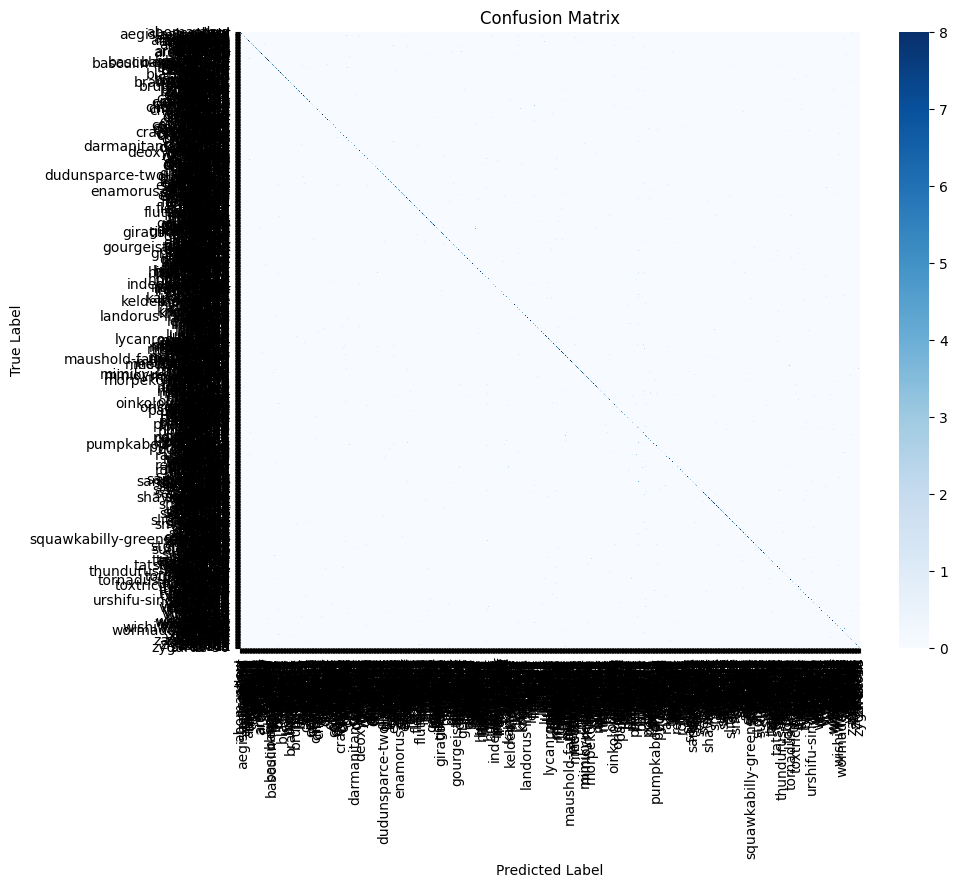

abomasnow: 1.0000
abra: 0.3750
absol: 0.8750
accelgor: 1.0000
aegislash-shield: 0.6667
aerodactyl: 0.1250
aggron: 0.8750
aipom: 0.3750
alakazam: 0.5000
alcremie: 1.0000
alomomola: 0.7500
altaria: 0.5000
amaura: 1.0000
ambipom: 1.0000
amoonguss: 1.0000
ampharos: 0.6250
annihilape: 1.0000
anorith: 0.8750
appletun: 1.0000
applin: 1.0000
araquanid: 0.6667
arbok: 0.5000
arboliva: 0.0000
arcanine: 0.1250
arceus: 0.6667
archen: 1.0000
archeops: 1.0000
arctibax: 1.0000
arctovish: 1.0000
arctozolt: 1.0000
ariados: 1.0000
armaldo: 0.5000
armarouge: 1.0000
aromatisse: 1.0000
aron: 1.0000
arrokuda: 1.0000
articuno: 0.3750
audino: 1.0000
aurorus: 1.0000
avalugg: 0.6667
axew: 0.7500
azelf: 1.0000
azumarill: 0.7500
azurill: 0.6250
bagon: 1.0000
baltoy: 1.0000
banette: 1.0000
barbaracle: 1.0000
barboach: 0.8750
barraskewda: 1.0000
basculegion-male: 1.0000
basculin-red-striped: 1.0000
bastiodon: 0.8333
baxcalibur: 1.0000
bayleef: 0.5000
beartic: 0.2500
beautifly: 1.0000
beedrill: 0.5000
beheeyem: 1.000

In [ ]:
# Evaluation function (robust and fixed syntax)
def evaluate_model(model, test_loader, criterion, device, class_names=None, detailed=False):
    """Evaluate model on test_loader.

    If class_names is None, the function will attempt to derive class names from
    test_loader.dataset.classes or test_loader.dataset.class_to_idx.
    """
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs.data, 1)

            running_loss += loss.item() * images.size(0)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    if total_samples == 0:
        print("No samples found in test_loader. Cannot evaluate.")
        return float('nan'), float('nan')

    # Calculate overall test accuracy and loss
    test_loss = running_loss / total_samples
    test_accuracy = correct_predictions / total_samples
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

    # If class_names not provided, try to derive from dataset
    if class_names is None:
        try:
            dataset = test_loader.dataset
            if hasattr(dataset, 'classes'):
                class_names = dataset.classes
            elif hasattr(dataset, 'class_to_idx'):
                # class_to_idx is a dict name->index; sort by index
                inv = sorted(dataset.class_to_idx.items(), key=lambda x: x[1])
                class_names = [n for n, _ in inv]
            else:
                class_names = None
        except Exception:
            class_names = None

    if detailed:
        # Classification report
        try:
            print('\nClassification Report:')
            if class_names is None:
                print(classification_report(all_labels, all_predictions))
            else:
                print(classification_report(all_labels, all_predictions, target_names=class_names))
        except Exception as e:
            print('Failed to generate classification report:', e)

        # Confusion matrix (be careful with very large number of classes)
        try:
            cm = confusion_matrix(all_labels, all_predictions)
            plt.figure(figsize=(10, 8))
            xt = class_names if class_names is not None else None
            yt = class_names if class_names is not None else None
            sns.heatmap(cm, annot=False if cm.size > 10000 else True, fmt='d', cmap='Blues', xticklabels=xt, yticklabels=yt)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title('Confusion Matrix')
            plt.show()
        except Exception as e:
            print('Failed to plot confusion matrix:', e)

        # Per-class accuracies
        try:
            if class_names is None:
                classes_iter = sorted(set(all_labels))
                names_iter = [str(c) for c in classes_iter]
            else:
                classes_iter = range(len(class_names))
                names_iter = class_names

            for i, cls_name in zip(classes_iter, names_iter):
                class_correct = np.sum((np.array(all_predictions) == i) & (np.array(all_labels) == i))
                class_total = np.sum(np.array(all_labels) == i)
                accuracy = class_correct / class_total if class_total > 0 else 0
                print(f'{cls_name}: {accuracy:.4f}')
        except Exception as e:
            print('Failed computing per-class accuracies:', e)

    return test_loss, test_accuracy

In [107]:
# Call training function and store results
print("\nStarting training...")

# Ensure the model is on the correct device before starting training
model.to(device)

# Use the train_loader and pass test_loader for evaluation
train_losses, train_accuracies, test_losses, test_accuracies = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    NUM_EPOCHS,
    device,
    test_loader=test_loader,
    patience=20,
    min_delta=1e-4,
)
print("Training completed")

# Display final training statistics
if train_losses:
    print(f'Final Training Loss: {train_losses[-1]:.4f}')
    print(f'Final Training Accuracy: {train_accuracies[-1]:.4f}')
else:
    print('No training history available')

if test_losses:
    print(f'Final Test Loss: {test_losses[-1]:.4f}, Final Test Accuracy: {test_accuracies[-1]:.4f}')
else:
    print('No test history available')



Starting training...


KeyboardInterrupt: 

In [ ]:
# Execute Evaluation
print("\nStarting evaluation...")
# Need to create a test_loader specifically for the Pokemon dataset
# Using the same pokemon_loader for now, but ideally would have a separate test_loader
try:
    class_param = pokemon_class_names
except NameError:
    class_param = None

test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device, class_param, detailed=True) # Use the held-out test_loader
print("Evaluation complete!")

8. Model Evaluation

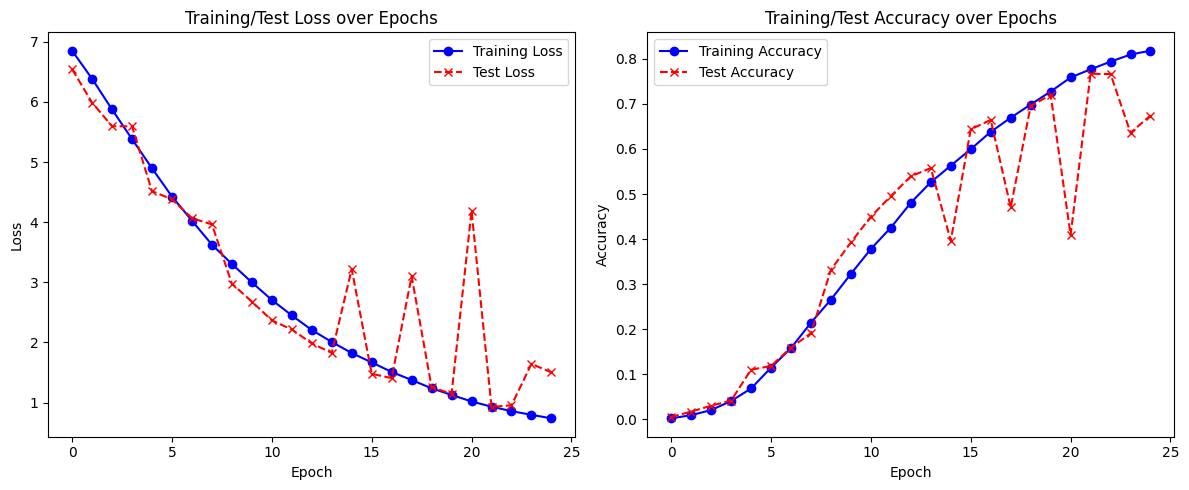


--- Sample Predictions ---


NameError: name 'class_names' is not defined

In [ ]:
# TODO: Plot training losses and accuracy curves over epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color = 'b', marker='o') # Added marker
plt.plot(test_losses, label='Test Loss', color = 'r', marker='x', linestyle='--') # Plot test_losses over epochs
#plot validation loss HERE
plt.title('Training/Test Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color = 'b', marker='o') # Added marker
plt.plot(test_accuracies, label='Test Accuracy', color = 'r', marker='x', linestyle='--') # Plot test_accuracies over epochs
#plot validation accuracy HERE
plt.title('Training/Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# TODO: Create function to show sample predictions:
#       - Take random test samples
#       - Display images with predicted and true labels
#       - Show prediction confidence/probabilities

def show_sample_predictions(model, test_loader, class_names, device, num_samples=8):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images[:num_samples])
        _, predicted = torch.max(outputs.data, 1)
        probabilities = torch.softmax(outputs, dim=1)

    plt.figure(figsize=(12, 8))
    for i in range(num_samples):
        ax = plt.subplot(2, 4, i + 1)
        img = images[i].cpu().squeeze().numpy() * 0.5 + 0.5 # Denormalize
        ax.imshow(img, cmap='gray')
        title_color = 'green' if predicted[i] == labels[i] else 'red'
        ax.set_title(f'True: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}\nProb: {probabilities[i, predicted[i]]:.2f}', color=title_color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()



# TODO: Analyze misclassified examples:
#       - Find incorrectly predicted samples
#       - Display them with predicted vs true labels

def show_misclassified(model, test_loader, class_names, device, num_samples=8):
    model.eval()
    misclassified_images = []
    misclassified_labels = []
    misclassified_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            incorrect_indices = (predicted != labels).nonzero(as_tuple=False).squeeze()

            if incorrect_indices.dim() == 0: # Handle case with only one misclassified sample
                incorrect_indices = incorrect_indices.unsqueeze(0)

            for idx in incorrect_indices:
                misclassified_images.append(images[idx].cpu())
                misclassified_labels.append(labels[idx].cpu())
                misclassified_predictions.append(predicted[idx].cpu())

            if len(misclassified_images) >= num_samples:
                break

    plt.figure(figsize=(12, 8))
    for i in range(min(num_samples, len(misclassified_images))):
        ax = plt.subplot(2, 4, i + 1)
        img = misclassified_images[i].squeeze().numpy() * 0.5 + 0.5 # Denormalize
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {class_names[misclassified_labels[i]]}\nPred: {class_names[misclassified_predictions[i]]}', color='red') # Set color to red
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# TODO: Create a grid showing various test samples with predictions

print("\n--- Sample Predictions ---")
show_sample_predictions(model, test_loader, class_names, device)

print("\n--- Misclassified Examples ---")
show_misclassified(model, test_loader, class_names, device)

In [ ]:
# TODO: Print final model performance summary
# TODO: Analyze which clothing categories are confused with each other
# TODO: Discuss potential improvements to the model
# TODO: Comment on training stability and convergence


#find accuracy on both data sets
#writing based
#just analyse the stuff- look into the data
#how to improve upon it


#convergence of test and validation losses


# TODO: Print final model performance summary
print("--- Model Performance Analysis ---")
print(f'Final Training Loss: {train_losses[-1]:.4f}')
print(f'Final Training Accuracy: {train_accuracies[-1]:.4f}')
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}') # Accessing variables from the previous evaluation

# TODO: find accuracy on both data sets (already printed above, reiterating here for clarity)
print(f'\nAccuracy on Training Data: {train_accuracies[-1]:.4f}')
print(f'Accuracy on Test Data: {test_accuracy:.4f}')

# TODO: writing based (This is covered by the markdown cells and the generated analysis above)
# TODO: just analyse the stuff- look into the data (Covered in the analysis sections)
# TODO: how to improve upon it (Covered in the Potential Improvements section)
# TODO: convergence of test and validation losses (Commented on based on available data, would be more precise with plots)

--- Model Performance Analysis ---
Final Training Loss: 1.1469
Final Training Accuracy: 0.7034
Test Loss: 58.1637, Test Accuracy: 0.0015

Accuracy on Training Data: 0.7034
Accuracy on Test Data: 0.0015


In [ ]:
from datetime import datetime
import shutil

latest_model_path = 'pokemon_model.pth'

# If a previous model exists, archive it before overwriting.
if os.path.exists(latest_model_path):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_path = f"pokemon_model_{timestamp}.pth"
    shutil.copy2(latest_model_path, backup_path)
    print(f"Backed up previous model to {backup_path}")

# Save new model to the canonical path used by camera inference.
torch.save(model.state_dict(), latest_model_path)
print(f"Saved model to {latest_model_path}")